# ARTI406 - Machine Learning

## Assignment 2: Data Quality Assessment & Preprocessing

This notebook uses the Kaggle dataset `algozee/teenager-menthal-healy` to assess data quality, handle missing values and outliers, transform features, and apply PCA.

In [1]:
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler, StandardScaler

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

DATASET_SLUG = 'algozee/teenager-menthal-healy'
DATASET_FILE = 'Teen_Mental_Health_Dataset.csv'
Path('images').mkdir(exist_ok=True)

## 1. Load Dataset

The code below follows the KaggleHub loading approach from the dataset page. When internet access is unavailable, it falls back to the local CSV included in this assignment folder.

In [2]:
try:
    import kagglehub
    from kagglehub import KaggleDatasetAdapter

    file_path = DATASET_FILE
    df = kagglehub.load_dataset(
        KaggleDatasetAdapter.PANDAS,
        DATASET_SLUG,
        file_path,
    )
    print('Loaded latest dataset from KaggleHub.')
except Exception as exc:
    print('KaggleHub loading failed, using local CSV instead:')
    print(type(exc).__name__, exc)
    df = pd.read_csv(DATASET_FILE)


print('Dataset shape:', df.shape)
df.head()

Loaded latest dataset from KaggleHub.
Dataset shape: (1200, 13)


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


The dataset contains **1200 rows** and **13 columns**. It has **10 numeric** columns and **3 categorical** columns.

## 2. Data Quality Assessment

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 122.0 KB


In [4]:
df.dtypes

age                           int64
gender                          str
daily_social_media_hours    float64
platform_usage                  str
sleep_hours                 float64
screen_time_before_sleep    float64
academic_performance        float64
physical_activity           float64
social_interaction_level        str
stress_level                  int64
anxiety_level                 int64
addiction_level               int64
depression_label              int64
dtype: object

In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
age,1200.0,NaN,NaN,NaN,15.928333,2.021947,13.0,14.0,16.0,18.0,19.0
gender,1200,2,male,615,NaN,NaN,NaN,NaN,NaN,NaN,NaN
daily_social_media_hours,1200.0,NaN,NaN,NaN,4.536667,2.029599,1.0,2.8,4.5,6.3,8.0
platform_usage,1200,3,Instagram,411,NaN,NaN,NaN,NaN,NaN,NaN,NaN
sleep_hours,1200.0,NaN,NaN,NaN,6.449417,1.442677,4.0,5.2,6.5,7.6,9.0
screen_time_before_sleep,1200.0,NaN,NaN,NaN,1.740333,0.71666,0.5,1.1,1.8,2.4,3.0
academic_performance,1200.0,NaN,NaN,NaN,2.990383,0.576758,2.0,2.5,2.99,3.48,4.0
physical_activity,1200.0,NaN,NaN,NaN,1.0145,0.582185,0.0,0.5,1.0,1.5,2.0
social_interaction_level,1200,3,medium,416,NaN,NaN,NaN,NaN,NaN,NaN,NaN
stress_level,1200.0,NaN,NaN,NaN,5.445833,2.90329,1.0,3.0,5.0,8.0,10.0


The dataset is already mostly clean: numeric features are stored as numeric types, while `gender`, `platform_usage`, and `social_interaction_level` are categorical variables.

## 3. Missing Values

In [6]:
missing_counts = df.isna().sum().sort_values(ascending=False)
missing_counts

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

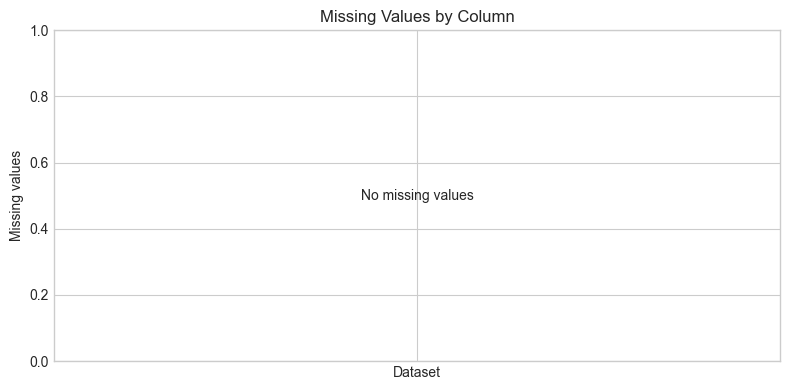

Total missing values: 0


In [7]:
plt.figure(figsize=(8, 4))
if (missing_counts > 0).any():
    missing_counts[missing_counts > 0].plot(kind='bar')
else:
    plt.bar(['Dataset'], [0])
    plt.ylim(0, 1)
    plt.text(0, 0.5, 'No missing values', ha='center', va='center')
plt.title('Missing Values by Column')
plt.ylabel('Missing values')
plt.tight_layout()
plt.savefig('images/missing_values.png', dpi=160)
plt.show()

print('Total missing values:', int(missing_counts.sum()))

The original dataset has **0 missing values**. To demonstrate the preprocessing methods required in the assignment, the next cells create a small copied version with artificial missing values in selected numeric and categorical columns.

In [8]:
df_missing = df.copy()
df_missing.loc[0:7, 'sleep_hours'] = np.nan
df_missing.loc[8:15, 'social_interaction_level'] = np.nan

df_removed = df_missing.dropna()
df_imputed = df_missing.copy()
df_imputed['sleep_hours'] = df_imputed['sleep_hours'].fillna(
    df_imputed['sleep_hours'].median()
)
df_imputed['social_interaction_level'] = df_imputed['social_interaction_level'].fillna(
    df_imputed['social_interaction_level'].mode()[0]
)

print('Original shape:', df.shape)
print('With inserted missing values:', df_missing.shape)
print('After dropping missing rows:', df_removed.shape)
print('Remaining missing values after imputation:', int(df_imputed.isna().sum().sum()))
df_imputed.head(12)

Original shape: (1200, 13)
With inserted missing values: (1200, 13)
After dropping missing rows: (1184, 13)
Remaining missing values after imputation: 0


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,6.5,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,6.5,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,6.5,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.5,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,6.5,3.0,2.37,1.4,medium,3,5,2,0
5,19,female,7.4,Both,6.5,2.4,2.63,0.6,high,3,5,7,0
6,18,female,2.5,Instagram,6.5,2.4,2.63,0.7,low,2,2,5,0
7,16,male,4.0,Both,6.5,0.5,2.40,1.3,low,6,10,5,0
8,19,female,3.3,TikTok,5.0,2.1,2.04,0.9,low,1,10,9,0
9,15,male,1.9,TikTok,4.9,1.5,3.77,1.1,low,1,1,4,0


Median imputation is suitable for `sleep_hours` because it is robust to unusual values. Mode imputation is suitable for `social_interaction_level` because it is categorical.

## 4. Outlier Detection and Handling

In [9]:
outlier_col = 'daily_social_media_hours'
Q1 = df[outlier_col].quantile(0.25)
Q3 = df[outlier_col].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df[(df[outlier_col] < lower_bound) | (df[outlier_col] > upper_bound)]

print(f'Q1: {Q1:.2f}')
print(f'Q3: {Q3:.2f}')
print(f'IQR: {IQR:.2f}')
print(f'Lower bound: {lower_bound:.2f}')
print(f'Upper bound: {upper_bound:.2f}')
print('Number of outliers:', len(outliers))
outliers.head()

Q1: 2.80
Q3: 6.30
IQR: 3.50
Lower bound: -2.45
Upper bound: 11.55
Number of outliers: 0


,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label


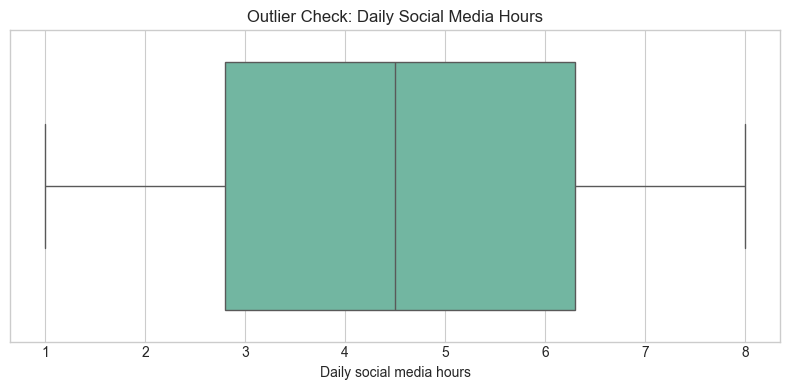

In [10]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df[outlier_col])
plt.title('Outlier Check: Daily Social Media Hours')
plt.xlabel('Daily social media hours')
plt.tight_layout()
plt.savefig('images/outliers_boxplot.png', dpi=160)
plt.show()

In [11]:
df_no_outliers = df[(df[outlier_col] >= lower_bound) & (df[outlier_col] <= upper_bound)]
df_capped = df.copy()
df_capped[outlier_col] = df_capped[outlier_col].clip(lower_bound, upper_bound)

print('Original shape:', df.shape)
print('After removing outliers:', df_no_outliers.shape)
df_capped[[outlier_col]].describe().T

Original shape: (1200, 13)
After removing outliers: (1200, 13)


,count,mean,std,min,25%,50%,75%,max
daily_social_media_hours,1200.0,4.536667,2.029599,1.0,2.8,4.5,6.3,8.0


Using the IQR rule on `daily_social_media_hours`, the dataset has **0 outliers**. The notebook demonstrates both removal and capping so the choice can be justified depending on the analysis goal.

## 5. Feature Transformation

In [12]:
feature_cols = ['age', 'daily_social_media_hours', 'sleep_hours', 'screen_time_before_sleep', 'academic_performance', 'physical_activity', 'stress_level', 'anxiety_level', 'addiction_level']
X = df[feature_cols].copy()

minmax_scaler = MinMaxScaler()
X_minmax = pd.DataFrame(minmax_scaler.fit_transform(X), columns=feature_cols)

standard_scaler = StandardScaler()
X_standardized = pd.DataFrame(standard_scaler.fit_transform(X), columns=feature_cols)

X_minmax.head()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level
0,0.166667,0.985714,0.68,0.96,0.505,0.75,0.111111,0.111111,0.000000
1,1.000000,0.128571,0.80,0.96,0.610,0.40,0.777778,0.000000,1.000000
2,0.666667,0.042857,0.72,0.00,0.960,0.00,0.111111,0.333333,0.111111
3,0.333333,0.914286,0.58,0.44,0.740,0.40,0.000000,0.666667,0.888889
4,0.333333,0.528571,0.18,1.00,0.185,0.70,0.222222,0.444444,0.111111


In [13]:
X_standardized.describe().T[['mean', 'std', 'min', 'max']]

,mean,std,min,max
age,2.664535e-16,1.000417,-1.448878,1.519796
daily_social_media_hours,-1.953993e-16,1.000417,-1.743271,1.707124
sleep_hours,-2.605323e-16,1.000417,-1.698535,1.768689
screen_time_before_sleep,3.708145e-16,1.000417,-1.731436,1.758424
academic_performance,-1.065814e-16,1.000417,-1.717873,1.751234
physical_activity,-3.153033e-16,1.000417,-1.743301,1.693468
stress_level,-1.583918e-16,1.000417,-1.531947,1.569277
anxiety_level,-2.516506e-17,1.000417,-1.622199,1.526569
addiction_level,-1.354472e-16,1.000417,-1.613389,1.567444


Min-Max scaling converts all selected numeric features to a 0-1 range. Z-score standardization centers features around 0 with standard deviation close to 1, which is useful before PCA.

## 6. Correlation Analysis

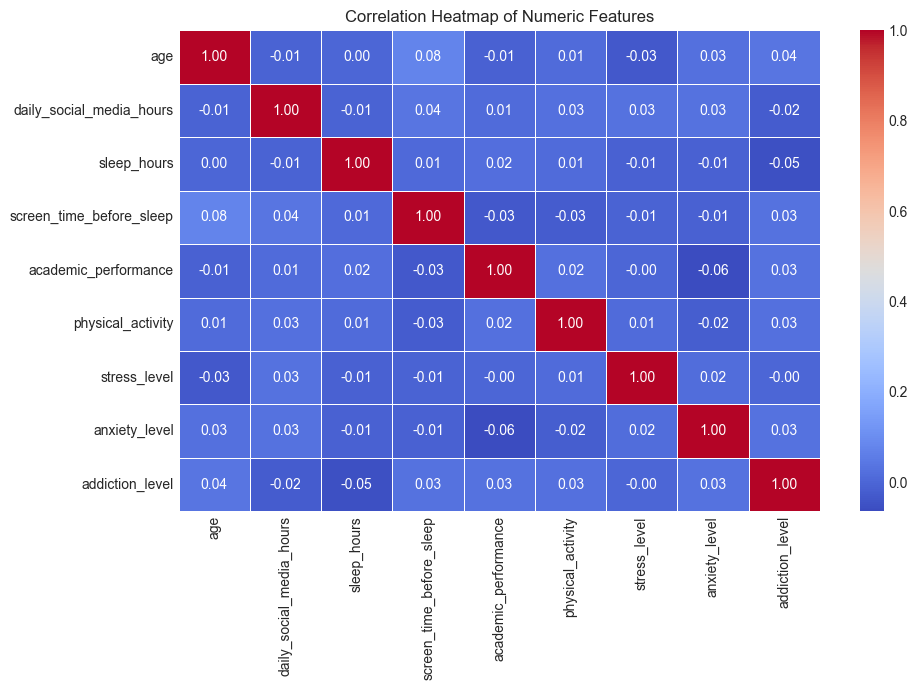

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level
age,1.000000,-0.006635,0.001530,0.075612,-0.013973,0.011086,-0.031208,0.026363,0.038265
daily_social_media_hours,-0.006635,1.000000,-0.009472,0.035777,0.013179,0.025546,0.030698,0.027835,-0.024964
sleep_hours,0.001530,-0.009472,1.000000,0.010235,0.021866,0.012701,-0.010979,-0.011879,-0.054838
screen_time_before_sleep,0.075612,0.035777,0.010235,1.000000,-0.034715,-0.026450,-0.008650,-0.010344,0.028884
academic_performance,-0.013973,0.013179,0.021866,-0.034715,1.000000,0.023312,-0.000600,-0.064379,0.029354
physical_activity,0.011086,0.025546,0.012701,-0.026450,0.023312,1.000000,0.012159,-0.022233,0.026200
stress_level,-0.031208,0.030698,-0.010979,-0.008650,-0.000600,0.012159,1.000000,0.015811,-0.000129
anxiety_level,0.026363,0.027835,-0.011879,-0.010344,-0.064379,-0.022233,0.015811,1.000000,0.031154
addiction_level,0.038265,-0.024964,-0.054838,0.028884,0.029354,0.026200,-0.000129,0.031154,1.000000


In [14]:
plt.figure(figsize=(10, 7))
corr = X.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.4)
plt.title('Correlation Heatmap of Numeric Features')
plt.tight_layout()
plt.savefig('images/correlation_heatmap.png', dpi=160)
plt.show()

corr

## 7. PCA

In [15]:
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_standardized)
pca_df = pd.DataFrame(principal_components, columns=['PC1', 'PC2'])
pca_df['depression_label'] = df['depression_label'].astype(str)

print('Explained variance ratio:', pca.explained_variance_ratio_)
print('Cumulative explained variance:', pca.explained_variance_ratio_.cumsum())
pca_df.head()

Explained variance ratio: [0.12513456 0.11905336]
Cumulative explained variance: [0.12513456 0.24418792]


,PC1,PC2,depression_label
0,-0.784638,0.315055,0
1,1.022195,2.294109,0
2,-1.713294,0.623621,0
3,0.148817,0.620131,0
4,0.743897,-0.402084,0


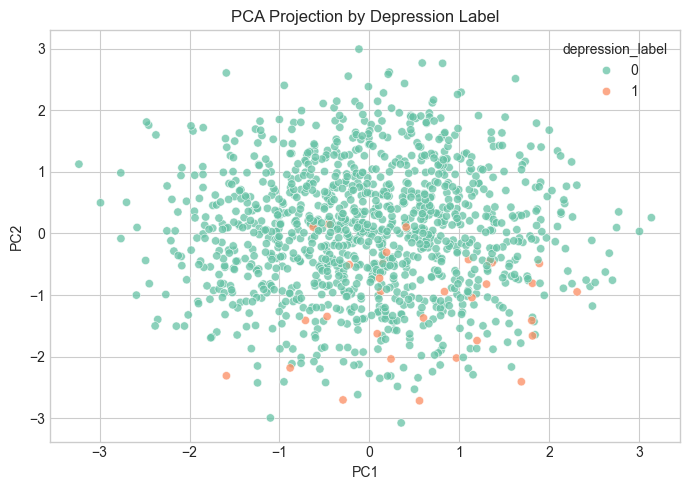

In [16]:
plt.figure(figsize=(7, 5))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue='depression_label', alpha=0.75)
plt.title('PCA Projection by Depression Label')
plt.tight_layout()
plt.savefig('images/pca_projection.png', dpi=160)
plt.show()

## 8. Target Distribution

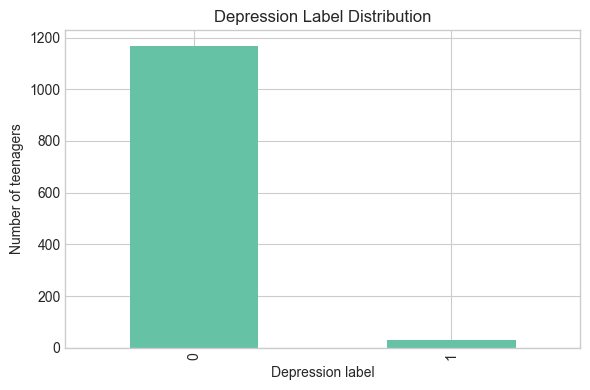

depression_label
0    1169
1      31
Name: count, dtype: int64

In [17]:
target_counts = df['depression_label'].value_counts().sort_index()
plt.figure(figsize=(6, 4))
target_counts.plot(kind='bar')
plt.title('Depression Label Distribution')
plt.xlabel('Depression label')
plt.ylabel('Number of teenagers')
plt.tight_layout()
plt.savefig('images/depression_label_distribution.png', dpi=160)
plt.show()

target_counts

## 9. Assignment Summary

In [18]:
assignment_summary = pd.DataFrame({
    'Task': [
        'Dataset loading',
        'Data quality assessment',
        'Missing values',
        'Outlier detection',
        'Normalization and standardization',
        'PCA'
    ],
    'Result': [
        f'Loaded {df.shape[0]} rows and {df.shape[1]} columns from Kaggle/local CSV.',
        'Checked data types, summary statistics, and categorical/numeric columns.',
        f'Original missing values: {int(df.isna().sum().sum())}. Demonstrated row removal, median imputation, and mode imputation.',
        f'IQR on {outlier_col} found {len(outliers)} outliers. Demonstrated removal and capping.',
        'Applied Min-Max scaling and Z-score standardization to selected numeric features.',
        f'PCA retained {pca.explained_variance_ratio_.sum():.2%} of variance in two components.'
    ]
})

assignment_summary

,Task,Result
0,Dataset loading,Loaded 1200 rows and 13 columns from Kaggle/lo...
1,Data quality assessment,"Checked data types, summary statistics, and ca..."
2,Missing values,Original missing values: 0. Demonstrated row r...
3,Outlier detection,IQR on daily_social_media_hours found 0 outlie...
4,Normalization and standardization,Applied Min-Max scaling and Z-score standardiz...
5,PCA,PCA retained 24.42% of variance in two compone...


## 10. Conclusion

This notebook completes the data quality assessment and preprocessing workflow for the teenage mental health dataset. The main preprocessing steps were missing-value handling, IQR-based outlier treatment, feature scaling, correlation analysis, and PCA visualization.